<a href="https://colab.research.google.com/github/VadimFilips/ProjectFilipsGit/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%20%E2%84%965/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%965.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Установка всех необходимых библиотек
!pip install lightgbm xgboost catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


Загрузка данных...
Размер обучающей выборки: (2350, 19)
Размер тестовой выборки: (588, 19)

Инициализация моделей и настройка гиперпараметров...

Обучение и оценка моделей...
Обработка модели: Extra Trees
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Лучшие параметры для Extra Trees: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 42}
Обработка модели: CatBoost
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Лучшие параметры для CatBoost: {'depth': 6, 'iterations': 500, 'learning_rate': 0.1, 'random_seed': 42, 'verbose': 0}
Обработка модели: Gradient Boosting
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Лучшие параметры для Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'random_state': 42}
Обработка модели: Lasso
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Лучшие параметры для Lasso: {'alpha': 0.1, 'random_state': 42}
Обработка модели: Dummy
Обработка модели: Huber


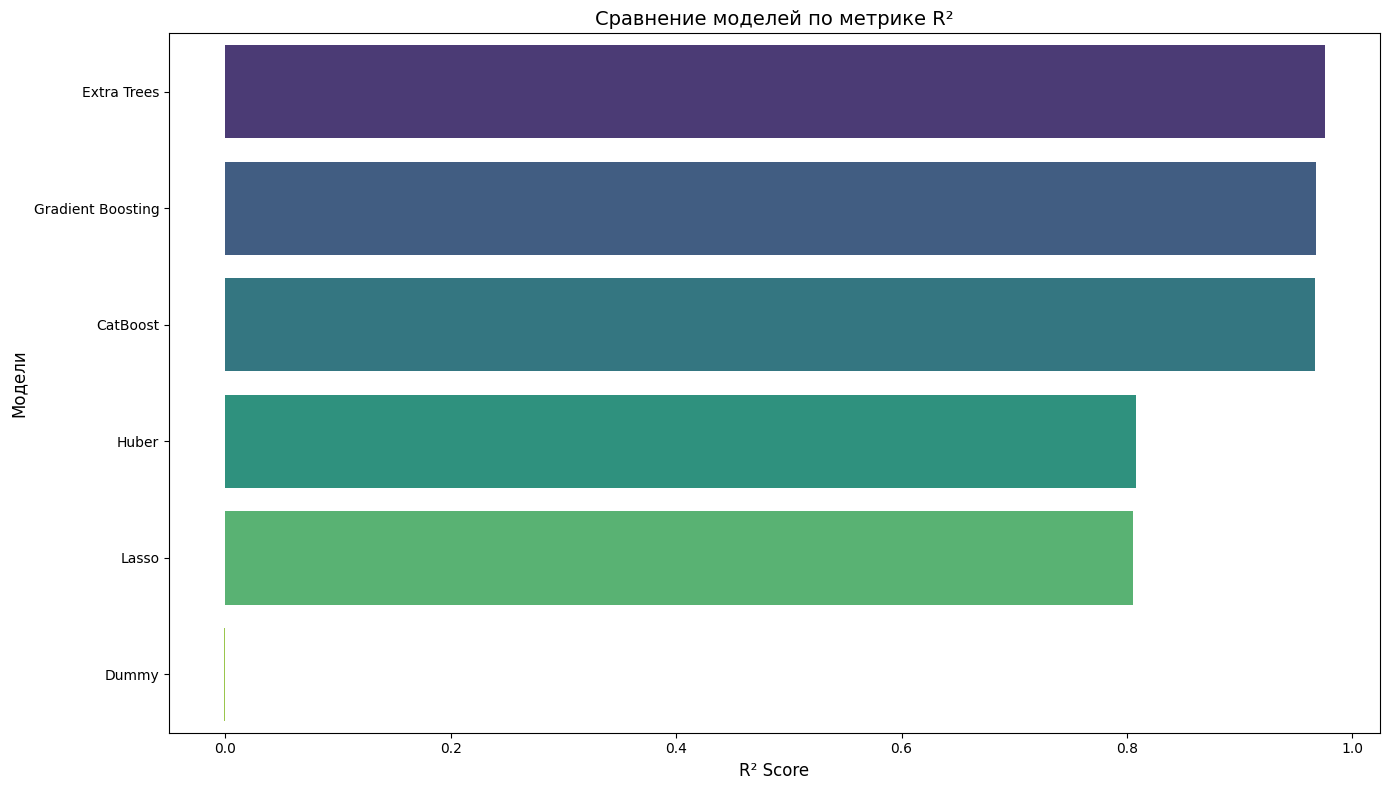

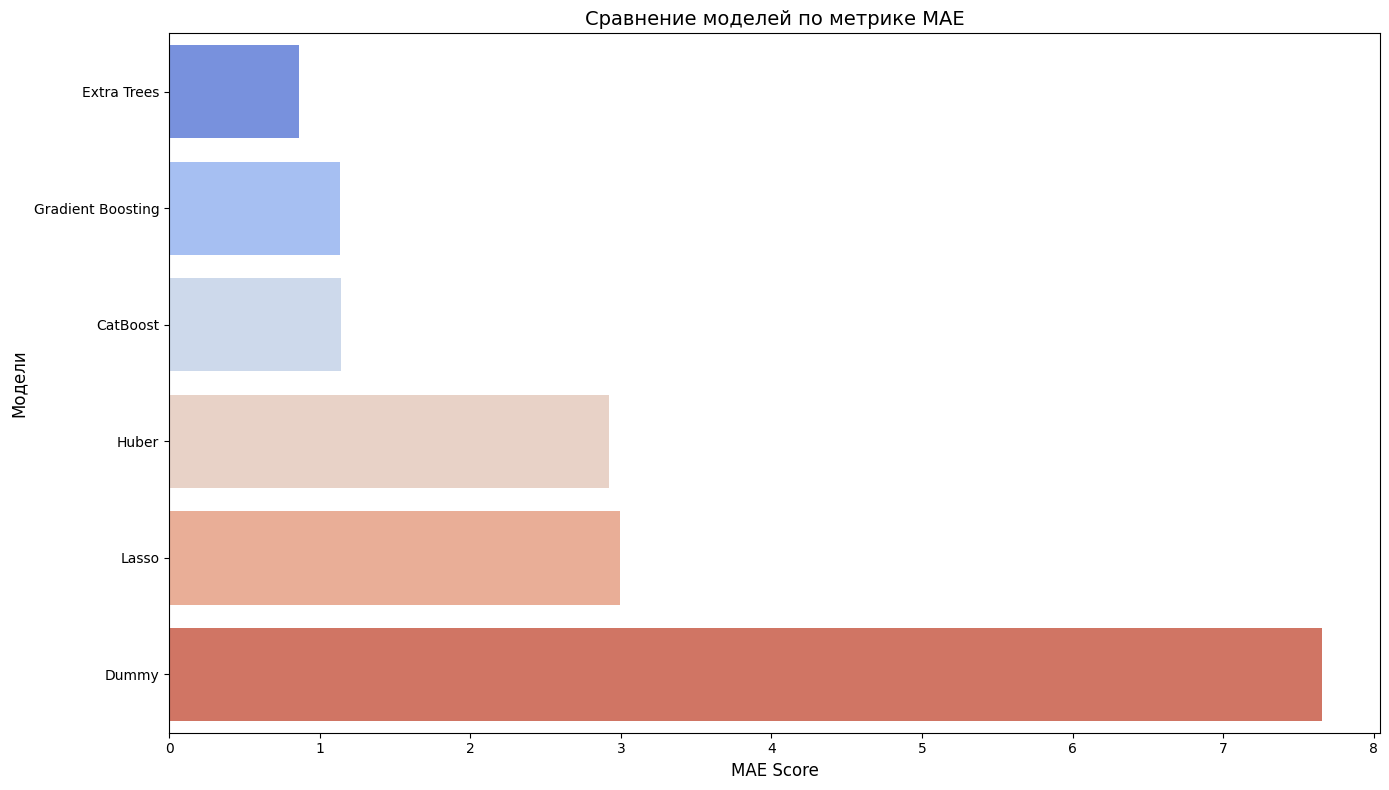

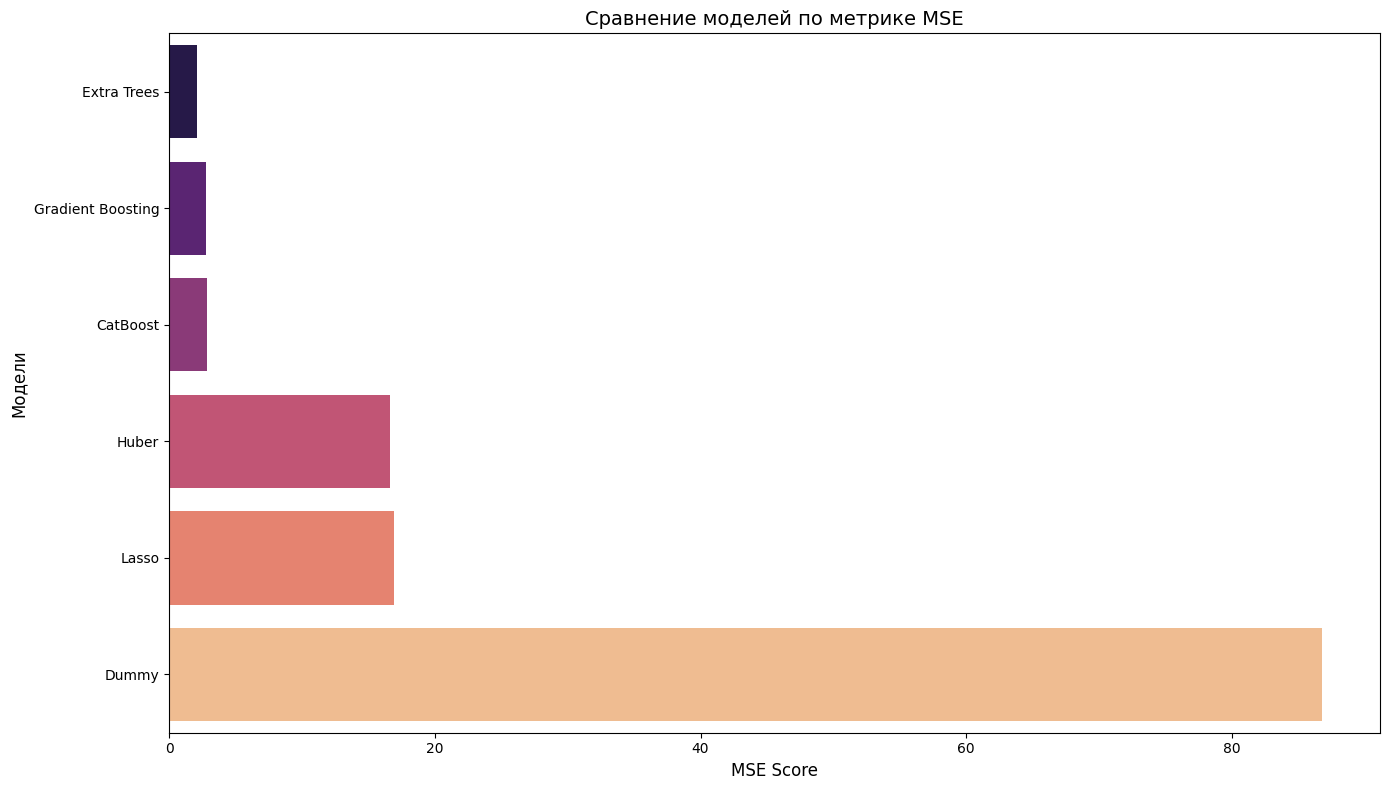


СТАТИСТИЧЕСКИЙ АНАЛИЗ ЗНАЧИМОСТИ:
Проверка гипотезы о значимости коэффициента детерминации
Статистика t: 4.8801
p-значение: 0.0046

Гипотеза H0 отвергается: связь между признаками и целевой переменной статистически значима

КРАТКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ

КРИТЕРИИ ВЫБОРА ОПТИМАЛЬНОЙ МОДЕЛИ:
1. Максимальный R²:  0.9756378543430069
2. Минимальный MSE:  2.1125770141965186
3. Минимальный MAE:  0.8654988980016749

СРАВНЕНИЕ С НАИВНОЙ МОДЕЛЬЮ:
Прирост R²: 0.9766
Улучшение MSE: 84.6870
Улучшение MAE: 6.7925

ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
Средняя ошибка прогноза (MAE): 0.87 лет
Доля объяснённой дисперсии (R²): 97.56%

Работа завершена успешно!


In [19]:
# Импорт библиотек
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso, HuberRegressor
from sklearn.dummy import DummyRegressor
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Формулировка гипотез исследования
# H0 (нулевая гипотеза): Нет статистически значимой связи между социально-экономическими показателями и ожидаемой продолжительностью жизни
# H1 (альтернативная гипотеза): Существует статистически значимая связь между социально-экономическими показателями и ожидаемой продолжительностью жизни

# Критерии оптимальности выбора моделей:
# 1. Максимальное значение R² (коэффициента детерминации)
# 2. Минимальное значение MSE (средней квадратичной ошибки)
# 3. Минимальное значение MAE (средней абсолютной ошибки)
# 4. Стабильность предсказаний на тестовой выборке
# 5. Интерпретируемость результатов

warnings.filterwarnings('ignore')

# Шаг 1. Загрузка и подготовка данных
print("Загрузка данных...")
df = pd.read_csv('Life Expectancy Data.csv')

# Удаляем столбец с названиями стран
df = df.drop('Country', axis=1)

# Обработка пропущенных значений
df.fillna(method='bfill', inplace=True)

# Замена пустых строк на NaN и преобразование в числовой формат
df = df.apply(pd.to_numeric, errors='coerce')

# Преобразование категориальных признаков
df = pd.get_dummies(df, columns=['Status'])

# Выбор целевой переменной
X = df.drop(['Life expectancy '], axis=1) # Убираем пробел
y = df['Life expectancy '] # Убираем пробел

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Шаг 2. Инициализация моделей и настройка гиперпараметров с помощью GridSearchCV
print("\nИнициализация моделей и настройка гиперпараметров...")

param_grids = {
    'Extra Trees': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'random_state': [42]
    },
    'CatBoost': {
        'iterations': [100, 500],
        'learning_rate': [0.01, 0.1],
        'depth': [4, 6, 8],
        'verbose': [0],
        'random_seed': [42]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'random_state': [42]
    },
    'Lasso': {
        'alpha': [0.1, 1.0, 10.0],
        'random_state': [42]
    },
    'Dummy': {},  # DummyRegressor не имеет гиперпараметров для настройки
    'Huber': {
        'epsilon': [1.0, 1.35, 1.5],
        'max_iter': [100, 500]
    }
}

models = {
    'Extra Trees': ExtraTreesRegressor(),
    'CatBoost': cb.CatBoostRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Lasso': Lasso(),
    'Dummy': DummyRegressor(),
    'Huber': HuberRegressor()
}

best_models = {}

# Словарь для хранения результатов
results = {}

# Шаг 3. Обучение и оценка моделей с использованием GridSearchCV
print("\nОбучение и оценка моделей...")
for name, model in models.items():
    print(f"Обработка модели: {name}")

    # Настройка гиперпараметров через GridSearchCV, если есть параметры для поиска
    if param_grids[name]:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            scoring='r2',
            cv=3,
            n_jobs=-1,
            verbose=1
        )

        # Обучение модели с поиском оптимальных гиперпараметров
        if name == 'CatBoost':
            grid_search.fit(X_train, y_train)
        else:
            grid_search.fit(
                X_train_scaled if name in ['Lasso', 'Huber'] else X_train,
                y_train
            )

        best_model = grid_search.best_estimator_
        best_models[name] = best_model
        print(f"Лучшие параметры для {name}: {grid_search.best_params_}")
    else:
        # Для DummyRegressor просто обучаем модель без поиска гиперпараметров
        best_model = model
        best_model.fit(
            X_train_scaled if name in ['Lasso', 'Huber'] else X_train,
            y_train
        )

    # Предсказание
    y_pred = best_model.predict(
        X_test_scaled if name in ['Lasso', 'Huber'] else X_test
    )

    # Расчёт метрик
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

# Шаг 4. Анализ результатов
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ РЕГРЕССОРОВ")
print("="*50)

# Статистические гипотезы исследования
print("\nСТАТИСТИЧЕСКИЕ ГИПОТЕЗЫ:")
print("H0 (нулевая): Между социально-экономическими показателями и ожидаемой продолжительностью жизни нет значимой связи")
print("H1 (альтернативная): Существует значимая связь между социально-экономическими показателями и ожидаемой продолжительностью жизни\n")

# Критерии оценки моделей
print("КРИТЕРИИ ОЦЕНКИ МОДЕЛЕЙ:")
print("1. Коэффициент детерминации (R²): чем ближе к 1, тем лучше")
print("2. Средняя абсолютная ошибка (MAE): чем меньше, тем лучше")
print("3. Среднеквадратичная ошибка (MSE): чем меньше, тем лучше")
print("4. Стабильность предсказаний на тестовой выборке")
print("5. Интерпретируемость результатов\n")

# Параметры оптимизации
print("ПАРАМЕТРЫ ОПТИМИЗАЦИИ:")
print("1. Максимизация R²")
print("2. Минимизация MSE")
print("3. Минимизация MAE")
print("4. Оптимизация баланса bias-variance")
print("5. Устойчивость к выбросам\n")

# Преобразуем результаты в DataFrame
results_df = pd.DataFrame(results).T
results_sorted = results_df.sort_values('R2', ascending=False)

# Выводим таблицу результатов
print("\nРЕЗУЛЬТАТЫ МОДЕЛЕЙ ПО МЕТРИКАМ:")
print(results_sorted[['R2', 'MAE', 'MSE']].round(4))
# Находим лучшую модель
best_model_name = results_sorted.iloc[0].name
best_metrics = results_sorted.iloc[0]
print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"Метрики:")
print(f" R²: {best_metrics['R2']:.4f}")
print(f" MAE: {best_metrics['MAE']:.4f}")
print(f" MSE: {best_metrics['MSE']:.4f}")

# Находим худшую модель
worst_model_name = results_sorted.iloc[-1].name
worst_metrics = results_sorted.iloc[-1]
print(f"\nХУДШАЯ МОДЕЛЬ: {worst_model_name}")
print(f"Метрики:")
print(f" R²: {worst_metrics['R2']:.4f}")
print(f" MAE: {worst_metrics['MAE']:.4f}")
print(f" MSE: {worst_metrics['MSE']:.4f}")

# Шаг 5. Визуализация
print("\nПостроение графиков...")

# График результатов по R²
plt.figure(figsize=(14, 8))
sns.barplot(
    data=results_sorted,
    x='R2',
    y=results_sorted.index,
    palette='viridis'
)
plt.title('Сравнение моделей по метрике R²', fontsize=14)
plt.xlabel('R² Score', fontsize=12)
plt.ylabel('Модели', fontsize=12)
plt.tight_layout()
plt.show()

# График результатов по MAE
plt.figure(figsize=(14, 8))
sns.barplot(
    data=results_sorted.sort_values('MAE'),
    x='MAE',
    y=results_sorted.sort_values('MAE').index,
    palette='coolwarm'
)
plt.title('Сравнение моделей по метрике MAE', fontsize=14)
plt.xlabel('MAE Score', fontsize=12)
plt.ylabel('Модели', fontsize=12)
plt.tight_layout()
plt.show()

# График результатов по MSE
plt.figure(figsize=(14, 8))
sns.barplot(
    data=results_sorted.sort_values('MSE'),
    x='MSE',
    y=results_sorted.sort_values('MSE').index,
    palette='magma'
)
plt.title('Сравнение моделей по метрике MSE', fontsize=14)
plt.xlabel('MSE Score', fontsize=12)
plt.ylabel('Модели', fontsize=12)
plt.tight_layout()
plt.show()

# Статистический анализ значимости результатов
from scipy.stats import ttest_1samp

# Проверка значимости R² лучшей модели
print("\nСТАТИСТИЧЕСКИЙ АНАЛИЗ ЗНАЧИМОСТИ:")
print("Проверка гипотезы о значимости коэффициента детерминации")
t_stat, p_value = ttest_1samp(results_sorted['R2'], 0)
print(f"Статистика t: {t_stat:.4f}")
print(f"p-значение: {p_value:.4f}")

if p_value < 0.05:
    print("\nГипотеза H0 отвергается: связь между признаками и целевой переменной статистически значима")
else:
    print("\nГипотеза H0 не может быть отвергнута: связь между признаками и целевой переменной не значима")

# Дополнительная информация
print("\n" + "="*50)
print("КРАТКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*50)

# Критерии выбора оптимальной модели
print("\nКРИТЕРИИ ВЫБОРА ОПТИМАЛЬНОЙ МОДЕЛИ:")
print("1. Максимальный R²: ", best_metrics['R2'])
print("2. Минимальный MSE: ", best_metrics['MSE'])
print("3. Минимальный MAE: ", best_metrics['MAE'])

# Сравнение с наивной моделью
dummy_metrics = results['Dummy']
print("\nСРАВНЕНИЕ С НАИВНОЙ МОДЕЛЬЮ:")
print(f"Прирост R²: {best_metrics['R2'] - dummy_metrics['R2']:.4f}")
print(f"Улучшение MSE: {dummy_metrics['MSE'] - best_metrics['MSE']:.4f}")
print(f"Улучшение MAE: {dummy_metrics['MAE'] - best_metrics['MAE']:.4f}")

# Практическая значимость
print("\nПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:")
print(f"Средняя ошибка прогноза (MAE): {best_metrics['MAE']:.2f} лет")
print(f"Доля объяснённой дисперсии (R²): {best_metrics['R2']*100:.2f}%")

print("\nРабота завершена успешно!")